In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
Converted from Jupyter Notebook: 2d_malafide.ipynb
Conversion Date: 2025-11-13T04:40:18.262Z
"""

# ## Data Preparation


!pip install tensorflow opencv-python tqdm scikit-learn matplotlib seaborn mtcnn

!pip install lz4

import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from mtcnn import MTCNN

# ==========================
# Setup Paths and Parameters
# ==========================
REAL_PATH = "FF++/real"
FAKE_PATH = "FF++/fake"
WORK_DIR = "working"
os.makedirs(WORK_DIR, exist_ok=True)

OUTPUT_FRAME_SIZE = (128, 128)
FRAME_COUNT = 10
MAX_VIDEOS = 200
CHECKPOINT_INTERVAL = 50  # save progress every 50 videos



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ==========================
# Verify dataset paths
# ==========================
if not os.path.exists(REAL_PATH) or not os.path.exists(FAKE_PATH):
    raise FileNotFoundError(f"Dataset paths not found. REAL_PATH={REAL_PATH}, FAKE_PATH={FAKE_PATH}")

detector = MTCNN()

# ==========================
# Helper functions
# ==========================
def extract_face(frame):
    results = detector.detect_faces(frame)
    if results:
        x, y, w, h = results[0]['box']
        x, y = max(0, x), max(0, y)
        face = frame[y:y+h, x:x+w]
        return cv2.resize(face, OUTPUT_FRAME_SIZE)
    return cv2.resize(frame, OUTPUT_FRAME_SIZE)

def extract_frames(video_path, output_size=(128, 128), frame_count=10):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Warning: Could not open {video_path}")
        return np.array([])
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(total_frames // frame_count, 1)
    for i in range(frame_count):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ret, frame = cap.read()
        if not ret:
            break
        frame = extract_face(frame)
        frames.append(frame)
    cap.release()
    return np.array(frames) if len(frames) > 0 else np.zeros((frame_count, output_size[0], output_size[1], 3), dtype=np.uint8)

# ==========================
# Load checkpoint if exists
# ==========================
checkpoint_file = os.path.join(WORK_DIR, "checkpoint.npy")
if os.path.exists(checkpoint_file):
    print("Loading checkpoint...")
    checkpoint = np.load(checkpoint_file, allow_pickle=True).item()
    data = checkpoint["data"]
    labels = checkpoint["labels"]
    processed_real = checkpoint["processed_real"]
    processed_fake = checkpoint["processed_fake"]
else:
    data, labels = [], []
    processed_real, processed_fake = 0, 0

# ==========================
# Process Real Videos
# ==========================
print("Processing real videos...")
real_videos = os.listdir(REAL_PATH)[:MAX_VIDEOS]
for i, video_file in enumerate(tqdm(real_videos[processed_real:]), start=processed_real):
    video_path = os.path.join(REAL_PATH, video_file)
    frames = extract_frames(video_path, OUTPUT_FRAME_SIZE, FRAME_COUNT)
    if len(frames) == FRAME_COUNT:
        data.append(frames)
        labels.append(0)
    processed_real += 1

    # Save checkpoint every 50 videos
    if processed_real % CHECKPOINT_INTERVAL == 0:
        np.save(checkpoint_file, {
            "data": data,
            "labels": labels,
            "processed_real": processed_real,
            "processed_fake": processed_fake
        })
        print(f"Checkpoint saved at {processed_real} real videos")

# ==========================
# Process Fake Videos
# ==========================
print("Processing fake videos...")
fake_videos = os.listdir(FAKE_PATH)[:MAX_VIDEOS]
for i, video_file in enumerate(tqdm(fake_videos[processed_fake:]), start=processed_fake):
    video_path = os.path.join(FAKE_PATH, video_file)
    frames = extract_frames(video_path, OUTPUT_FRAME_SIZE, FRAME_COUNT)
    if len(frames) == FRAME_COUNT:
        data.append(frames)
        labels.append(1)
    processed_fake += 1

    # Save checkpoint every 50 videos
    if processed_fake % CHECKPOINT_INTERVAL == 0:
        np.save(checkpoint_file, {
            "data": data,
            "labels": labels,
            "processed_real": processed_real,
            "processed_fake": processed_fake
        })
        print(f"Checkpoint saved at {processed_fake} fake videos")

# ==========================
# Final Save
# ==========================
if len(data) == 0:
    raise ValueError("No valid frames extracted.")

data = np.array(data)
labels = np.array(labels)

# Split dataset
X_train, X_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Normalize
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=2)
y_val = to_categorical(y_val, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)

# Save final outputs
np.save(os.path.join(WORK_DIR, "X_train.npy"), X_train)
np.save(os.path.join(WORK_DIR, "y_train.npy"), y_train)
np.save(os.path.join(WORK_DIR, "X_val.npy"), X_val)
np.save(os.path.join(WORK_DIR, "y_val.npy"), y_val)
np.save(os.path.join(WORK_DIR, "X_test.npy"), X_test)
np.save(os.path.join(WORK_DIR, "y_test.npy"), y_test)

# Save final checkpoint (for traceability)
np.save(os.path.join(WORK_DIR, "final_checkpoint.npy"), {
    "processed_real": processed_real,
    "processed_fake": processed_fake,
    "total_data": len(data)
})

print(f"✅ Data saved successfully in {WORK_DIR}")
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Files:", os.listdir(WORK_DIR))


# ## Data Augmentation


from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=40,
    zoom_range=0.4,
    brightness_range=[0.5, 1.5],
    shear_range=0.4,
    width_shift_range=0.3,
    height_shift_range=0.3,
    channel_shift_range=10.0,
    fill_mode='nearest'
)

def augment_frames(frames):
    augmented_frames = []
    for frame in frames:
        frame = datagen.random_transform(frame)
        augmented_frames.append(frame)
    return np.array(augmented_frames)

augmented_data = []
augmented_labels = []

for i in tqdm(range(len(X_train))):
    augmented_frames = augment_frames(X_train[i])
    augmented_data.append(augmented_frames)
    augmented_labels.append(y_train[i])

X_train_augmented = np.concatenate((X_train, np.array(augmented_data)))
y_train_augmented = np.concatenate((y_train, np.array(augmented_labels)))

print(f"Augmented Train Data: {X_train_augmented.shape}")
np.save(os.path.join(WORK_DIR, "X_train_augmented.npy"), X_train_augmented)
np.save(os.path.join(WORK_DIR, "Y_train_augmented.npy"), y_train_augmented)
print(f"files: ", os.listdir(WORK_DIR))

Processing real videos...


 25%|████████████████████▎                                                            | 50/200 [07:04<19:25,  7.77s/it]

Checkpoint saved at 50 real videos


 50%|████████████████████████████████████████                                        | 100/200 [13:32<13:45,  8.26s/it]

Checkpoint saved at 100 real videos


...

100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [28:00<00:00,  8.40s/it]

Checkpoint saved at 200 fake videos


✅ Data saved successfully in working
Train: (280, 10, 128, 128, 3) Val: (60, 10, 128, 128, 3) Test: (60, 10, 128, 128, 3)
Files: ['checkpoint.npy', 'final_checkpoint.npy', 'X_test.npy', 'X_train.npy', 'X_val.npy', 'y_test.npy', 'y_train.npy', 'y_val.npy']


100%|████████████████████████████████████████████████████████████████████████████████| 280/280 [00:14<00:00, 19.76it/s]


Augmented Train Data: (560, 10, 128, 128, 3)
files:  ['checkpoint.npy', 'final_checkpoint.npy', 'X_test.npy', 'X_train.npy', 'X_train_augmented.npy', 'X_val.npy', 'y_test.npy', 'y_train.npy', 'Y_train_augmented.npy', 'y_val.npy']


In [12]:
# ## Model Architecture


import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, TimeDistributed, Bidirectional, GRU, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2

def build_meso4_model(input_shape=(FRAME_COUNT, 128, 128, 3)):
    import tensorflow as tf
    from tensorflow.keras.layers import (
        Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
        Activation, BatchNormalization, TimeDistributed, Bidirectional, GRU
    )
    from tensorflow.keras.models import Model, Sequential
    from tensorflow.keras.regularizers import l2

    # Frame-level CNN (Meso4)
    frame_input = Input(shape=(128, 128, 3))

    x = Conv2D(8, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.001))(frame_input)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.1)(x)

    x = Conv2D(8, (5, 5), padding='same', activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.15)(x)

    x = Conv2D(16, (5, 5), padding='same', activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.2)(x)

    x = Conv2D(16, (5, 5), padding='same', activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(4, 4))(x)
    x = Dropout(0.25)(x)

    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    frame_cnn = Model(inputs=frame_input, outputs=x, name='Meso4_FrameCNN')

    # Video-level temporal model
    model = Sequential([
        TimeDistributed(frame_cnn, input_shape=input_shape),
        BatchNormalization(),
        Bidirectional(GRU(128, return_sequences=False, kernel_regularizer=l2(0.005))),
        Dropout(0.5),
        Dense(64, activation='relu', kernel_regularizer=l2(0.005)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(2, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Use this new Meso4 model
model = build_meso4_model()
model.summary()


C:\Users\simra\anaconda3\Lib\site-packages\keras\src\layers\core\wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ time_distributed_1 (TimeDistributed) │ (None, 10, 128)             │          44,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 10, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 256)                 │         198,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 260,042 (1015.79 KB)

 Trainable params: 259,562 (1013.91 KB)

 Non-trainable params: 480 (1.88 KB)

In [13]:

# ## Model Training


import os
import json
import pandas as pd
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from sklearn.utils import class_weight

# ==========================
# Setup directories
# ==========================
WORK_DIR = "./working"
os.makedirs(WORK_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(WORK_DIR, "deepfake_detection_best.keras")
FINAL_MODEL_PATH = os.path.join(WORK_DIR, "deepfake_detection_final.keras")
HISTORY_JSON_PATH = os.path.join(WORK_DIR, "training_history.json")
HISTORY_CSV_PATH = os.path.join(WORK_DIR, "training_history.csv")

# ==========================
# Compute class weights
# ==========================
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(np.argmax(y_train, axis=1)),
    y=np.argmax(y_train, axis=1)
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weight_dict)

# ==========================
# Callbacks
# ==========================
checkpoint = ModelCheckpoint(
    BEST_MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# ==========================
# Train the model
# ==========================
history = model.fit(
    X_train_augmented, y_train_augmented,
    validation_data=(X_val, y_val),
    epochs=100,  # Increase to ~100 for full training
    batch_size=8,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, lr_scheduler],
    verbose=1
)

# ==========================
# Save the final model
# ==========================
model.save(FINAL_MODEL_PATH)
print(f"✅ Final model saved at: {FINAL_MODEL_PATH}")

# ==========================
# Save training history
# ==========================
history_dict = history.history

# Save as JSON
with open(HISTORY_JSON_PATH, "w") as f:
    json.dump(history_dict, f, indent=4)
print(f"📘 Training history saved as JSON at: {HISTORY_JSON_PATH}")

# Save as CSV
pd.DataFrame(history_dict).to_csv(HISTORY_CSV_PATH, index=False)
print(f"📗 Training history saved as CSV at: {HISTORY_CSV_PATH}")

# ==========================
# Verify saved files
# ==========================
print("\n📁 Files saved in working directory:")
for f in os.listdir(WORK_DIR):
    print(" -", f)


Class weights: {0: 1.0144927536231885, 1: 0.9859154929577465}
Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.5142 - loss: 3.7417
Epoch 1: val_accuracy improved from -inf to 0.43333, saving model to ./working\deepfake_detection_best.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 47s 235ms/step - accuracy: 0.5140 - loss: 3.7414 - val_accuracy: 0.4333 - val_loss: 3.1940 - learning_rate: 1.0000e-04
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.5159 - loss: 3.7552
Epoch 2: val_accuracy did not improve from 0.43333
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 186ms/step - accuracy: 0.5158 - loss: 3.7547 - val_accuracy: 0.4000 - val_loss: 3.2191 - learning_rate: 1.0000e-04
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.5489 - loss: 3.5127
Epoch 3: val_accuracy did not improve from 0.43333
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 184ms/step - accuracy: 0.5486 - loss: 3.5133 - val_accuracy: 0.4167 - val_loss: 3.2048 - learning_rate: 1.0000e-04
Epoch 4/100
70/70 ━━━━━━━━━━

✅ Model loaded successfully from ./working\deepfake_detection_best.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step

🎯 Test Accuracy: 53.33%

📊 Classification Report:
              precision    recall  f1-score   support

        REAL       0.60      0.45      0.52        33
        FAKE       0.49      0.63      0.55        27

    accuracy                           0.53        60
   macro avg       0.54      0.54      0.53        60
weighted avg       0.55      0.53      0.53        60

💾 Training history saved successfully.


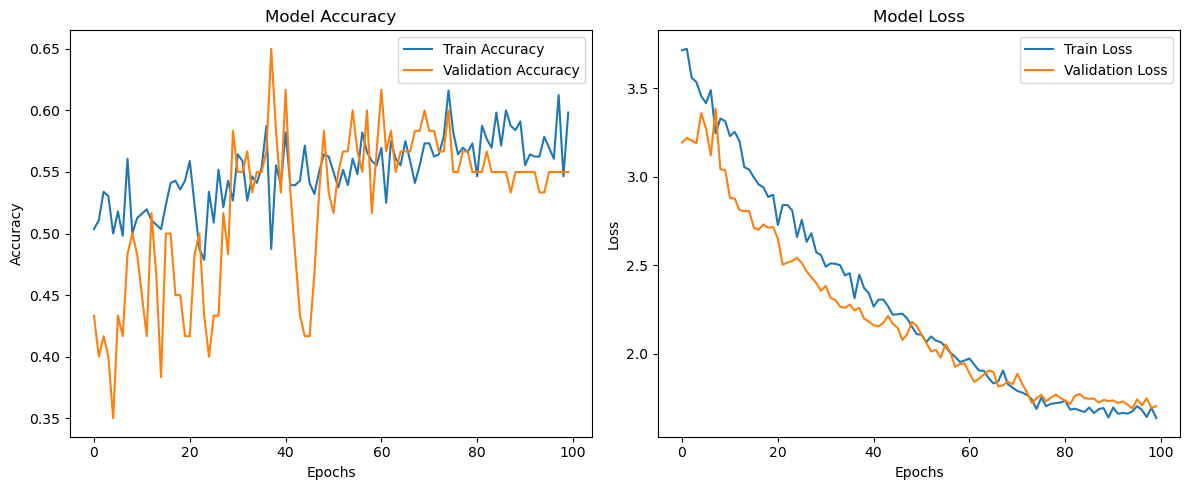

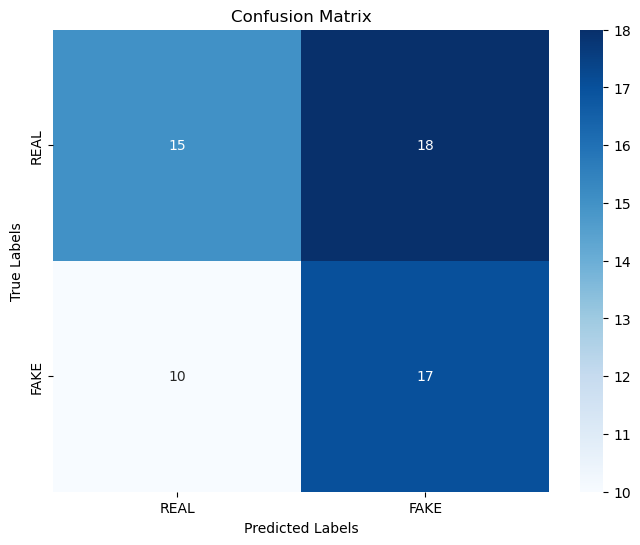


Detailed Classification Report:
              precision    recall  f1-score   support

        REAL       0.60      0.45      0.52        33
        FAKE       0.49      0.63      0.55        27

    accuracy                           0.53        60
   macro avg       0.54      0.54      0.53        60
weighted avg       0.55      0.53      0.53        60

Model loaded successfully from ./working\deepfake_detection_best.keras
Real Video Prediction:
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: REAL (Confidence: 0.92)
Fake Video Prediction:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Prediction: REAL (Confidence: 0.94)


In [14]:
# ## Model Testing


# --- Evaluation & Visualization ---

from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

# --- Load trained model ---
model_path = os.path.join(WORK_DIR, "deepfake_detection_best.keras")
final_model_path = os.path.join(WORK_DIR, "deepfake_detection_final.keras")

try:
    model = load_model(model_path)
    print(f"✅ Model loaded successfully from {model_path}")
except Exception as e:
    print(f"⚠️ Could not load {model_path}. Trying final model instead.")
    model = load_model(final_model_path)
    print(f"✅ Model loaded successfully from {final_model_path}")

# --- Predict & Evaluate ---
y_pred = model.predict(X_test, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

accuracy = accuracy_score(y_true, y_pred_classes)
print(f"\n🎯 Test Accuracy: {accuracy * 100:.2f}%")
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=['REAL', 'FAKE']))

# --- Load training history if running in new session ---
if 'history' not in locals():
    try:
        history = joblib.load("training_history.pkl")
        print("✅ Training history loaded successfully.")
    except:
        print("⚠️ No history found. Skipping training plot.")

# --- Plot training history ---
def plot_training_history(history):
    if history is None:
        print("⚠️ No history available to plot.")
        return

    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# --- Confusion Matrix Plot ---
def plot_confusion_matrix(model, X_test, y_test):
    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true, y_pred_classes)
    labels = ['REAL', 'FAKE']

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

    print("\nDetailed Classification Report:")
    print(classification_report(y_true, y_pred_classes, target_names=labels))

# --- Save history for future sessions ---
try:
    joblib.dump(history, "training_history.pkl")
    print("💾 Training history saved successfully.")
except:
    print("⚠️ Could not save training history (ignored).")

# --- Run plots ---
plot_training_history(history)
plot_confusion_matrix(model, X_test, y_test)




# ## Real Time Detection
# 


# Real-Time Detection
import cv2
import numpy as np
import os
from tensorflow.keras.models import load_model

# Function to extract frames from a video
def extract_frames(video_path, output_size=(128, 128), frame_count=10):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video file {video_path}")
        return np.array([])  # Return empty array if video fails to open
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(total_frames // frame_count, 1)  # Uniform sampling
    
    for i in range(frame_count):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, output_size)  # Resize frame
        frames.append(frame)
    cap.release()
    
    # Convert to NumPy array and ensure 4D shape
    if len(frames) == 0:
        print(f"Warning: No frames extracted from {video_path}")
        return np.zeros((0, output_size[0], output_size[1], 3), dtype=np.uint8)
    return np.array(frames, dtype=np.uint8)

# Function to predict video
def predict_video(video_path, model, output_size=(128, 128), frame_count=10):
    frames = extract_frames(video_path, output_size, frame_count)
    if len(frames) == 0:
        print(f"Error: No frames to predict for {video_path}")
        return
    
    # Ensure frames is 4D
    if len(frames.shape) == 3:  # (height, width, channels)
        frames = np.expand_dims(frames, axis=0)  # Make it (1, height, width, channels)
    elif len(frames.shape) == 4 and frames.shape[0] < frame_count:
        pad_length = frame_count - frames.shape[0]
        pad_width = [(0, pad_length)] + [(0, 0) for _ in range(len(frames.shape) - 1)]
        frames = np.pad(frames, pad_width, mode='constant', constant_values=0)
    elif len(frames.shape) != 4:
        print(f"Error: Unexpected frame shape {frames.shape} for {video_path}")
        return

    frames = frames / 255.0  # Normalize
    frames = np.expand_dims(frames, axis=0)  # Add batch dimension
    prediction = model.predict(frames)
    label = "FAKE" if np.argmax(prediction) == 1 else "REAL"
    confidence = float(prediction[0][np.argmax(prediction)])
    print(f"Prediction: {label} (Confidence: {confidence:.2f})")

# Load the model with file existence check
model_path = os.path.join(WORK_DIR, "deepfake_detection_best.keras")
final_model_path = os.path.join(WORK_DIR, "deepfake_detection_final.keras")
if os.path.exists(model_path):
    loaded_model = load_model(model_path)
    print(f"Model loaded successfully from {model_path}")
else:
    print(f"Error: Model file not found at {model_path}. Please run the training section first.")
    raise FileNotFoundError(f"Model file not found at {model_path}")

# Use the same dataset paths as data loading
REAL_PATH = "FF++/real"
FAKE_PATH = "FF++/fake"

# Get the first available video files (verify they exist)
real_videos = os.listdir(REAL_PATH)
fake_videos = os.listdir(FAKE_PATH)
if not real_videos or not fake_videos:
    print("Error: No video files found in REAL_PATH or FAKE_PATH. Check dataset input.")
else:
    real_sample_path = os.path.join(REAL_PATH, real_videos[0])  # First real video
    fake_sample_path = os.path.join(FAKE_PATH, fake_videos[0])  # First fake video

    # Test predictions
    print("Real Video Prediction:")
    predict_video(real_sample_path, loaded_model)

    print("Fake Video Prediction:")
    predict_video(fake_sample_path, loaded_model)